# 05. 行列分解・SVD・PCA — 回転・伸縮・回転に分解する

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 5. Definition |
| Applied | 6. Computation 〜 10. Exercises |
| Advanced | 11. Advanced Notes |

## 1. Big Picture

数を素因数分解するように、行列も「素性の良い部品」に分解できます。

| 分解 | 部品 | 一言でいうと |
|---|---|---|
| LU | 下三角 × 上三角 | 掃き出し法の作業記録 |
| QR | 直交 × 上三角 | Gram-Schmidt の作業記録 |
| Cholesky | $LL^\top$ | 対称正定値行列専用の「平方根」 |
| 固有値分解 | $PDP^{-1}$ | 固有軸で見れば伸縮だけ(03 章) |
| **SVD** | **回転 × 伸縮 × 回転** | **どんな行列でも必ずできる究極の分解** |

主役は SVD(特異値分解)です。
**任意の行列による変換は「回転 → 軸ごとの伸縮 → 回転」の 3 ステップに分解できる。**
この事実から、画像圧縮(低ランク近似)とデータ分析の PCA が直接出てきます。

## 2. Problem — 3 つの実務的な問い

**問 1(高速化)** 同じ係数行列 $A$ で、右辺 $b$ だけ違う方程式を 1 万回解きたい。
毎回掃き出し法をやり直すのは無駄では?
→ $A$ を一度 LU 分解しておけば、あとは三角行列の代入計算だけで済む。

**問 2(圧縮)** $1000 \times 1000$ の画像(100 万個の数)を、できるだけ少ない数で
「だいたい」復元できる形に圧縮したい。何を残して何を捨てるべきか?
→ SVD が「重要な成分から順に」並べてくれる。

**問 3(データの要約)** 6 銘柄の株のリターンは互いに相関している。
実質的に何本の「独立な動き」があるのか? 一番大事な動きはどれか?
→ 共分散行列の固有値分解 = PCA が答える。

## 3. Intuition — 分解とは「変換の設計図」

行列をいきなり見ても、それがどんな変換か分かりません。
しかし「回転 $\to$ 伸縮 $\to$ 回転」に分解されていれば、各部品は完全に理解できます。

- **直交行列(回転・鏡映)**: 形を保つ。情報を失わない。
- **対角行列(伸縮)**: 各軸を独立に伸び縮み。性質がすべて対角成分に見えている。
- **三角行列**: 上から(下から)順番に代入で解ける。

分解 = 「理解できない 1 個」を「理解できる部品の積」に変えること。

## 4. Visualization — SVD を目で見る

単位円がどう変形されるかで SVD を見ます。任意の $A$ について

$$
A = U \Sigma V^\top
$$

- $V^\top$: 回転(入力側の直交基底に合わせる)
- $\Sigma$: 軸ごとの伸縮(伸縮率が **特異値** $\sigma_1 \ge \sigma_2 \ge \dots \ge 0$)
- $U$: 回転(出力側の直交基底へ)

円は必ず **楕円** に移り、楕円の半径が特異値、軸の向きが $U$ の列です。

In [1]:
# Shared setup.
import numpy as np
import matplotlib.pyplot as plt

from la_book import plotting
from la_book.datasets import make_correlated_cloud, make_test_image
from la_book.decompositions import (
    cholesky, compression_ratio, lowrank_errors, lu, pca_fit, qr, svd_lowrank, whiten,
)

np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(0)

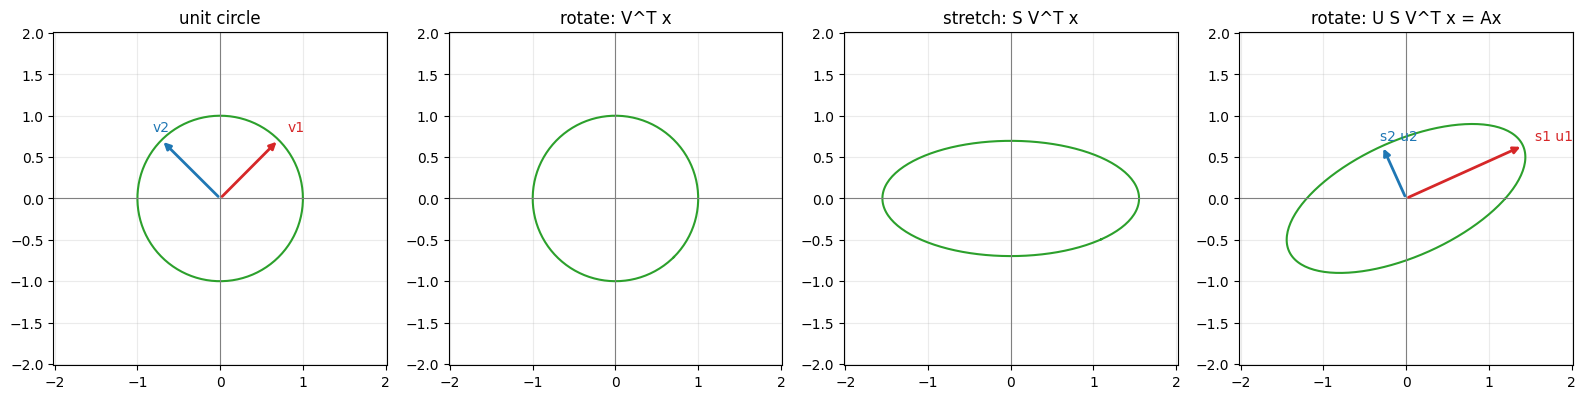

singular values: [1.551 0.696]


In [2]:
# Any matrix = rotate, stretch, rotate: watch the unit circle.
A = np.array([[1.2, 0.8],
              [0.0, 0.9]])
plotting.plot_svd_action(A)
plt.show()

U, s, Vt = np.linalg.svd(A)
print("singular values:", s)

## 5. Definition — 各分解の定義

**LU 分解**: 正方行列を(行交換 $P$ 付きで)$A = PLU$ に分解。
$L$ は対角 1 の下三角、$U$ は上三角。掃き出し法で「どの行に何倍を足したか」を
$L$ に記録したものです。

**QR 分解**: $A = QR$。$Q$ の列は正規直交、$R$ は上三角。
Gram-Schmidt(04 章)の結果を行列でまとめた形。

**Cholesky 分解**: 対称正定値行列だけが持つ特権的な分解 $A = LL^\top$。
LU の半分の計算量で、数の平方根の行列版。

**スペクトル定理**: 対称行列 $A = A^\top$ は必ず

$$
A = Q \Lambda Q^\top
$$

と分解できる($Q$ は直交、$\Lambda$ は実対角)。
固有値は実数、固有ベクトルは直交に取れる — 対称行列は固有値分解の「優等生」です。

**SVD(特異値分解)**: 任意の $m \times n$ 行列が

$$
A = U \Sigma V^\top
$$

と分解できる($U, V$ は直交行列、$\Sigma$ は非負の対角)。
固有値分解と違い、**正方でなくても、対称でなくても、必ず存在** します。
ランク = 0 でない特異値の個数、という最も安定したランクの定義も与えます。

**低ランク近似(Eckart-Young の定理)**: 特異値を大きい方から $k$ 個だけ残した

$$
A_k = \sum_{i=1}^{k} \sigma_i u_i v_i^\top
$$

は、ランク $k$ 以下の行列の中で $A$ に最も近い(Frobenius ノルムでもスペクトルノルムでも)。
**「最良の要約」が SVD の切り捨てで得られる** — 圧縮と PCA の理論的根拠です。

## 6. Computation — 分解を確かめ、使う

In [3]:
# LU: the bookkeeping of Gaussian elimination. Solve many systems fast.
from scipy.linalg import lu_factor, lu_solve

A_sq = rng.standard_normal((4, 4))
P, L, U_tri = lu(A_sq)
print("reconstruction error ||PLU - A|| =", np.linalg.norm(P @ L @ U_tri - A_sq))

# Factor once, then solve for many right-hand sides cheaply.
lu_piv = lu_factor(A_sq)
B = rng.standard_normal((4, 3))           # three right-hand sides
X = np.column_stack([lu_solve(lu_piv, B[:, i]) for i in range(3)])
print("max residual over 3 solves:", np.abs(A_sq @ X - B).max())

reconstruction error ||PLU - A|| = 1.1631705747361534e-16
max residual over 3 solves: 2.220446049250313e-16


In [4]:
# QR and Cholesky.
A_tall = rng.standard_normal((6, 3))
Q, R = qr(A_tall)
print("QR: ||QR - A|| =", np.linalg.norm(Q @ R - A_tall),
      "  ||Q^T Q - I|| =", np.linalg.norm(Q.T @ Q - np.eye(3)))

M = rng.standard_normal((3, 3))
S_pd = M @ M.T + 3 * np.eye(3)            # symmetric positive definite
L_chol = cholesky(S_pd)
print("Cholesky: ||L L^T - S|| =", np.linalg.norm(L_chol @ L_chol.T - S_pd))

QR: ||QR - A|| = 6.955527313080394e-16   ||Q^T Q - I|| = 5.689939390643248e-16
Cholesky: ||L L^T - S|| = 3.236828524569469e-16


In [5]:
# Spectral theorem: symmetric matrices have orthogonal eigenvectors (use eigh).
S_sym = np.array([[2.0, 1.0], [1.0, 2.0]])
lam, Q_eig = np.linalg.eigh(S_sym)
print("eigenvalues (real):", lam)
print("Q^T Q =\n", Q_eig.T @ Q_eig)
print("||Q diag(lam) Q^T - S|| =", np.linalg.norm(Q_eig @ np.diag(lam) @ Q_eig.T - S_sym))

eigenvalues (real): [1. 3.]
Q^T Q =
 [[1. 0.]
 [0. 1.]]
||Q diag(lam) Q^T - S|| = 6.473657049138938e-16


### SVD による画像圧縮

$128 \times 128$ の合成画像(16,384 個の数)を SVD し、特異値の減衰と、
ランク $k$ 近似の見た目を確認します。
保存すべき数は $k(m + n + 1)$ 個 — ランク 20 なら元の約 31% です。

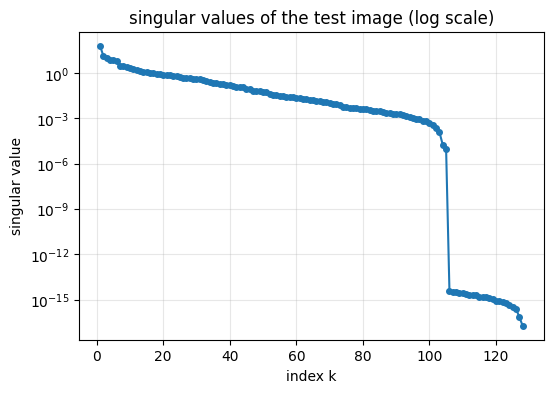

In [6]:
# Singular values of an image decay fast: most information sits in the first few.
img = make_test_image(128)
s_img = np.linalg.svd(img, compute_uv=False)
plotting.plot_singular_spectrum(s_img)
plt.title("singular values of the test image (log scale)")
plt.show()

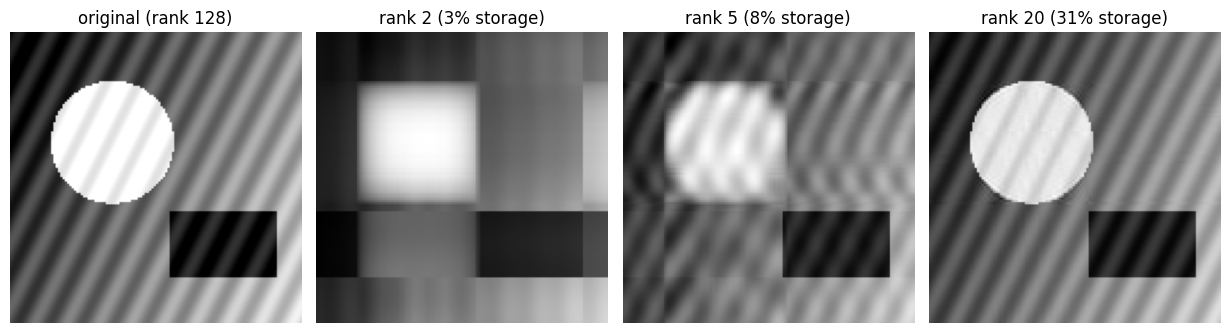

rank  2: ||A - A_k||_F =  17.924, storage = 3%
rank  5: ||A - A_k||_F =   9.773, storage = 8%
rank 20: ||A - A_k||_F =   2.015, storage = 31%


In [7]:
# Visual quality vs rank: best rank-k approximations (Eckart-Young).
plotting.show_image_ranks(img, ks=[2, 5, 20])
plt.show()

errs = lowrank_errors(img, ks=[2, 5, 20])
for k, e in zip([2, 5, 20], errs, strict=True):
    print(f"rank {k:>2}: ||A - A_k||_F = {e:7.3f}, storage = {compression_ratio(img.shape, k):.0%}")

In [8]:
# Interactive (JupyterLab only): slide k and watch the image sharpen.
from la_book.widgets import interactive_rank

interactive_rank(img)

interactive(children=(IntSlider(value=10, description='rank k', max=128, min=1), Output()), _dom_classes=('wid…

<function la_book.widgets.interactive_rank.<locals>.draw(k)>

### PCA — ばらつきが大きい方向を探す

データ行列 $X$($n$ 行 = 観測、列 = 変数)を中心化し、その SVD(または共分散行列の固有値分解)で
**分散が最大の方向 = 第 1 主成分** を見つけるのが PCA です。

共分散行列との関係は:

$$
\Sigma = \frac{1}{n-1} X_c^\top X_c = V \frac{\Sigma_s^2}{n-1} V^\top
$$

つまり **主成分方向 = 共分散行列の固有ベクトル = $X_c$ の右特異ベクトル**、
**主成分の分散 = 固有値 = 特異値の 2 乗 / (n-1)** です。

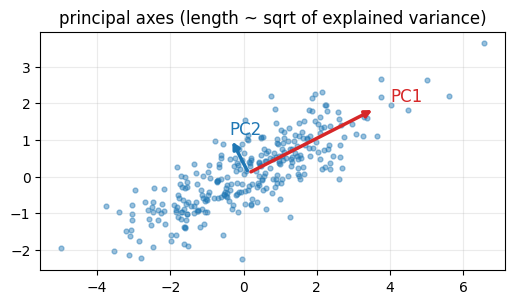

explained variance       : [3.755 0.273]
explained variance ratio : [0.932 0.068]


In [9]:
# PCA on a correlated 2-D cloud: PC1 is the direction of maximum variance.
X = make_correlated_cloud(n=300, seed=0)
res = pca_fit(X)

plotting.plot_pca_axes(X, res)
plt.title("principal axes (length ~ sqrt of explained variance)")
plt.show()

print("explained variance       :", res.explained_variance)
print("explained variance ratio :", res.explained_variance_ratio)

In [10]:
# Three roads to the same answer: our SVD-based PCA, covariance eigh, sklearn.
from sklearn.decomposition import PCA as SkPCA

Xc = X - X.mean(axis=0)
cov = Xc.T @ Xc / (len(X) - 1)
lam_cov, V_cov = np.linalg.eigh(cov)
sk = SkPCA(n_components=2).fit(X)

print("variance  ours   :", res.explained_variance)
print("variance  eigh   :", lam_cov[::-1])
print("variance  sklearn:", sk.explained_variance_)
print("PC1 ours    :", res.components[0])
print("PC1 sklearn :", sk.components_[0], " (sign may flip)")

variance  ours   : [3.755 0.273]
variance  eigh   : [3.755 0.273]
variance  sklearn: [3.755 0.273]
PC1 ours    : [0.891 0.453]
PC1 sklearn : [0.891 0.453]  (sign may flip)


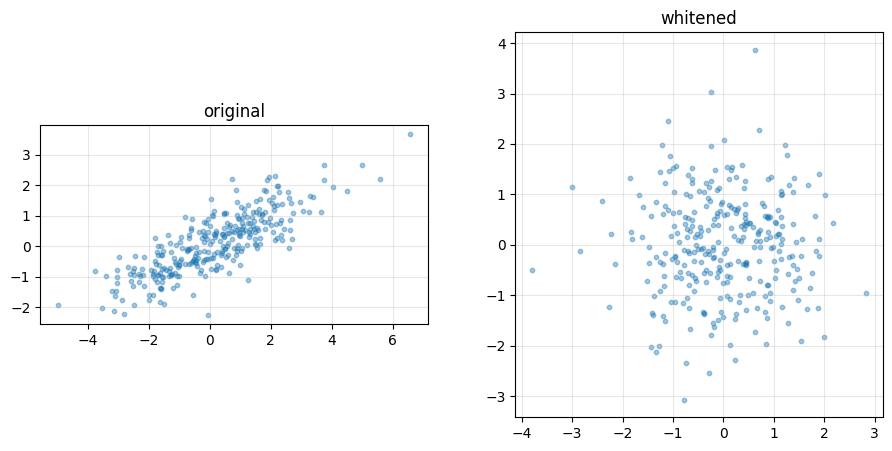

covariance of whitened data:
 [[1. 0.]
 [0. 1.]]


In [11]:
# Whitening: rotate to principal axes and rescale -> identity covariance.
Z, W = whiten(X)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, data, title in [(axes[0], X, "original"), (axes[1], Z, "whitened")]:
    ax.scatter(data[:, 0], data[:, 1], s=10, alpha=0.4)
    ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.set_title(title)
plt.show()
print("covariance of whitened data:\n", Z.T @ Z / (len(Z) - 1))

## 7. Invariant — 直交変換が保存するもの

- **特異値は回転で不変**: $A \mapsto Q_1 A Q_2$($Q_i$ 直交)としても特異値は同じ。
  特異値は「行列の本質的な伸縮率」であり、座標の取り方に依存しない。
- **Frobenius ノルムは特異値で決まる**: $\|A\|_F^2 = \sum_i \sigma_i^2$。
- **PCA は全分散を保存する**: 主成分への変換は回転なので、
  分散の合計(= 固有値の和 = trace $\Sigma$)は変わらない。
  PCA は分散を「捨てる」のではなく「並べ替えて」、上位に集中させているだけです。

In [12]:
# Singular values are invariant under orthogonal transforms; ||A||_F^2 = sum(s^2).
A_test = rng.standard_normal((4, 3))
Q1, _ = np.linalg.qr(rng.standard_normal((4, 4)))
Q2, _ = np.linalg.qr(rng.standard_normal((3, 3)))

print("s(A)      :", np.linalg.svd(A_test, compute_uv=False))
print("s(Q1 A Q2):", np.linalg.svd(Q1 @ A_test @ Q2, compute_uv=False))
print("||A||_F^2 =", np.linalg.norm(A_test, 'fro')**2,
      " sum s^2 =", (np.linalg.svd(A_test, compute_uv=False)**2).sum())

# PCA preserves total variance (it is just a rotation of centered data).
print("\ntotal variance before:", np.var(Xc, axis=0, ddof=1).sum())
print("total variance after :", res.explained_variance.sum())

s(A)      : [2.43  1.739 1.117]
s(Q1 A Q2): [2.43  1.739 1.117]
||A||_F^2 = 10.178072792426738  sum s^2 = 10.178072792426734

total variance before: 4.027796888622203
total variance after : 4.027796888622204


## 8. Failure Mode — 分解が壊れるとき・PCA の誤用

**(1) Cholesky は正定値でないと失敗する。** 失敗自体が「正定値性の検査」として使えます。

In [13]:
# Cholesky fails loudly on a non-positive-definite matrix.
bad = np.array([[1.0, 2.0],
                [2.0, 1.0]])   # eigenvalues 3 and -1
print("eigenvalues:", np.linalg.eigvalsh(bad))
try:
    np.linalg.cholesky(bad)
except np.linalg.LinAlgError as e:
    print("Cholesky failed as expected:", e)

eigenvalues: [-1.  3.]
Cholesky failed as expected: Matrix is not positive definite


**(2) 中心化を忘れた PCA。** 平均を引かずに PCA すると、
第 1 主成分は「データの広がる方向」ではなく「原点から平均への方向」を向いてしまいます。

In [14]:
# Forgetting to center the data sends PC1 toward the mean, not the spread.
X_shift = X + np.array([10.0, 10.0])           # same cloud, moved away from origin
_, _, Vt_nc = np.linalg.svd(X_shift)           # no centering!
res_ok = pca_fit(X_shift)                      # proper PCA centers internally

print("PC1 without centering:", Vt_nc[0], " (points toward the mean)")
print("PC1 with centering   :", res_ok.components[0])

PC1 without centering: [-0.712 -0.702]  (points toward the mean)
PC1 with centering   : [0.891 0.453]


**(3) スケールの混在。** 「身長 (m)」と「体重 (kg)」のように単位が違う変数を
そのまま PCA すると、数値が大きい変数が主成分を独占します。
変数ごとに標準化(分散 1 に)してから PCA するのが定石です(= 相関行列ベースの PCA)。

## 9. Application — どこで効いているか

- **画像・動画・音声の圧縮と雑音除去**: 低ランク近似はノイズ除去でもある
  (小さい特異値成分はほぼノイズ)。
- **レコメンド**: ユーザー × 商品の巨大行列を低ランク分解し、
  「少数の潜在的な好みの軸」で説明する(行列分解法)。
- **自然言語処理**: 単語共起行列の SVD(LSA)は word embedding の原型。
- **金融**: リターンの共分散行列の固有値分解 = リスクファクター分解(07 章で実装)。
- **統計・ML の前処理**: 白色化、次元削減、可視化(高次元データの 2 次元投影)。

## 10. Exercises

1. $A = \begin{pmatrix} 3 & 0 \\ 4 & 5 \end{pmatrix}$ の特異値を手で求めよ
   (ヒント: $A^\top A$ の固有値の平方根)。`np.linalg.svd` で検算せよ。
2. ランダムな $5 \times 5$ 行列を LU 分解し、$L, U$ の三角性と $PLU = A$ を確認せよ。
3. `make_test_image` の画像で、Frobenius 誤差がちょうど
   $\sqrt{\sum_{i>k} \sigma_i^2}$ になることを数値で確認せよ(Eckart-Young)。
4. 相関の強い 2 変数データを自分で生成し、PCA の第 1 主成分が
   散布図の「長軸」を向くことを確認せよ。寄与率はいくつか?
5. データの単位を変えて(片方の列を 100 倍して)PCA をやり直し、
   主成分がどう変わるか観察せよ。標準化で直ることも確認せよ。
6. (発展)$A_k = \sum_{i \le k} \sigma_i u_i v_i^\top$ を自分で実装し、
   `svd_lowrank` と一致することを確認せよ。

## 11. Advanced Notes

**スペクトル定理の証明スケッチ。** 対称 $A$ の固有値が実数であること:
$Av = \lambda v$ の両辺と $\bar v$ の内積を取り、$\bar v^\top A v$ が実数(対称性より自己共役)
であることから $\lambda \in \mathbb{R}$。直交性: $\lambda \neq \mu$ の固有ベクトル $v, w$ で
$\lambda v^\top w = (Av)^\top w = v^\top (Aw) = \mu v^\top w$ なので $v^\top w = 0$。
あとは次元についての帰納法で直交基底を構成します。

**SVD の存在証明スケッチ。** $A^\top A$ は対称半正定値なので、スペクトル定理で
$A^\top A = V \Lambda V^\top$($\Lambda \ge 0$)。$\sigma_i = \sqrt{\lambda_i}$、
$u_i = Av_i / \sigma_i$($\sigma_i > 0$ のもの)と置くと $u_i$ が正規直交になることが確認でき、
$A = U\Sigma V^\top$ が組み上がります。
**SVD は「$A^\top A$ と $AA^\top$ のスペクトル定理を同時に使う」分解** だと言えます。

**Eckart-Young の定理(スペクトルノルム版)の証明スケッチ。**
ランク $k$ の任意の $B$ について、$\mathrm{Ker}\,B$ は次元 $n - k$ 以上。
一方 $v_1, \dots, v_{k+1}$ の張る空間は次元 $k+1$ なので、両者は非自明に交わる。
その交わりの単位ベクトル $z$ で $\|(A - B)z\| = \|Az\| \ge \sigma_{k+1}$。
よって $\|A - B\|_2 \ge \sigma_{k+1} = \|A - A_k\|_2$。

**擬似逆行列(Moore-Penrose)。** $A^+ = V \Sigma^+ U^\top$($\Sigma^+$ は 0 でない特異値の逆数)。
最小二乗解は $\hat x = A^+ b$ と書け、ランク落ちしていても「ノルム最小の最小二乗解」を返します。
`np.linalg.pinv` / `np.linalg.lstsq` の中身です。

**数値計算上の注意。** PCA を「共分散行列を作って `eigh`」で計算すると、
条件数が 2 乗されます($X^\top X$ の形成、06 章参照)。
データ行列の SVD を直接取る方が数値的に安全で、`pca_fit` もそうしています。